## Importing Datasets

In [117]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [118]:
df = pd.read_csv("cleaned_dataset.csv")

## Basic Information

In [119]:
df

,Airline,Source,Destination,Duration,Total_Stops,Price,Date,Month,ArrivalTime_Hours,ArrivalTime_Min,DepTime_Hours,DepTime_Min
0,IndiGo,Banglore,New Delhi,170,0,3897,24,3,1,10,22,20
1,Air India,Kolkata,Banglore,445,2,7662,1,5,13,15,5,50
2,Jet Airways,Delhi,Cochin,1140,2,13882,9,6,4,25,9,25
3,IndiGo,Kolkata,Banglore,325,1,6218,12,5,23,30,18,5
4,IndiGo,Banglore,New Delhi,285,1,13302,1,3,21,35,16,50
...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,150,0,4107,9,4,22,25,19,55
10679,Air India,Kolkata,Banglore,155,0,4145,27,4,23,20,20,45
10680,Jet Airways,Banglore,Delhi,180,0,7229,27,4,11,20,8,20
10681,Vistara,Banglore,New Delhi,160,0,12648,1,3,14,10,11,30


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Airline            10683 non-null  object
 1   Source             10683 non-null  object
 2   Destination        10683 non-null  object
 3   Duration           10683 non-null  int64 
 4   Total_Stops        10683 non-null  int64 
 5   Price              10683 non-null  int64 
 6   Date               10683 non-null  int64 
 7   Month              10683 non-null  int64 
 8   ArrivalTime_Hours  10683 non-null  int64 
 9   ArrivalTime_Min    10683 non-null  int64 
 10  DepTime_Hours      10683 non-null  int64 
 11  DepTime_Min        10683 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 1001.7+ KB


In [121]:
df.shape

(10683, 12)

## Checking Null Values

In [122]:
df.isnull().sum()

Airline              0
Source               0
Destination          0
Duration             0
Total_Stops          0
Price                0
Date                 0
Month                0
ArrivalTime_Hours    0
ArrivalTime_Min      0
DepTime_Hours        0
DepTime_Min          0
dtype: int64

## Correlations 

<Axes: >

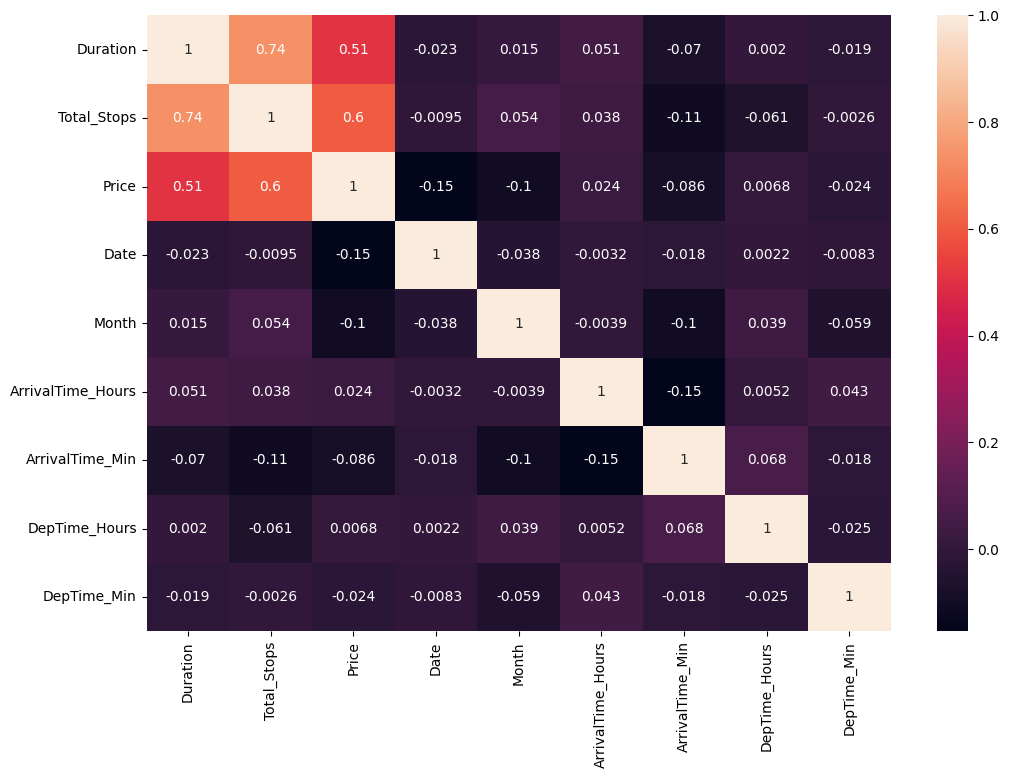

In [123]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True),annot=True)

## One Hot Encoding

In [124]:
df = pd.get_dummies(df,columns=['Airline','Source','Destination'])

## Feature Scaling

In [125]:
df['Price_Category'] = pd.qcut(df['Price'], q=3, labels=[0,1,2])
df

,Duration,Total_Stops,Price,Date,Month,ArrivalTime_Hours,ArrivalTime_Min,DepTime_Hours,DepTime_Min,Airline_Air Asia,...,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Price_Category
0,170,0,3897,24,3,1,10,22,20,False,...,False,False,False,False,False,False,False,False,True,0
1,445,2,7662,1,5,13,15,5,50,False,...,False,True,False,True,False,False,False,False,False,1
2,1140,2,13882,9,6,4,25,9,25,False,...,True,False,False,False,True,False,False,False,False,2
3,325,1,6218,12,5,23,30,18,5,False,...,False,True,False,True,False,False,False,False,False,0
4,285,1,13302,1,3,21,35,16,50,False,...,False,False,False,False,False,False,False,False,True,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,150,0,4107,9,4,22,25,19,55,True,...,False,True,False,True,False,False,False,False,False,0
10679,155,0,4145,27,4,23,20,20,45,False,...,False,True,False,True,False,False,False,False,False,0
10680,180,0,7229,27,4,11,20,8,20,False,...,False,False,False,False,False,True,False,False,False,1
10681,160,0,12648,1,3,14,10,11,30,False,...,False,False,False,False,False,False,False,False,True,2


## Converting the Data types into int

In [126]:
df = df.astype(int)

## Droppig the unneccesary data

In [127]:
df.drop('Price',axis=1,inplace=True)

## Separating the input and output variables

In [128]:
x=df.drop('Price_Category',axis=1)
y=df['Price_Category']

## Train-Test-Split

In [129]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Standard Scaling

In [130]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training

### First we will do Hyper Parameter Traning using RandomSearchCV and then train our models

## Decision Tree Classifier

In [131]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

In [132]:
param_dist_dt = {
    'max_depth': [5, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=42)

In [133]:
random_search_dt = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist_dt,
    n_iter=20,          # number of random combinations
    cv=3,               # 3-fold CV
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

In [134]:
random_search_dt.fit(X_train, y_train)
y_pred = random_search_dt.predict(X_test)
print("Decision Tree")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Decision Tree
[[630  67  13]
 [ 58 517 158]
 [  9 150 535]]
              precision    recall  f1-score   support

           0       0.90      0.89      0.90       710
           1       0.70      0.71      0.70       733
           2       0.76      0.77      0.76       694

    accuracy                           0.79      2137
   macro avg       0.79      0.79      0.79      2137
weighted avg       0.79      0.79      0.79      2137



## Random Forest

In [135]:
from sklearn.ensemble import RandomForestClassifier

In [136]:
param_dist_rf = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}

# Initialize model
rf = RandomForestClassifier(random_state=42)

In [137]:
random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=20,          # fewer iterations for speed
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)


In [138]:
random_search_rf.fit(X_train, y_train)
y_pred = random_search_rf.predict(X_test)
print("random Search")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

random Search
[[633  63  14]
 [ 67 491 175]
 [  3 129 562]]
              precision    recall  f1-score   support

           0       0.90      0.89      0.90       710
           1       0.72      0.67      0.69       733
           2       0.75      0.81      0.78       694

    accuracy                           0.79      2137
   macro avg       0.79      0.79      0.79      2137
weighted avg       0.79      0.79      0.79      2137



### Saving the created model into a file 

In [140]:
import joblib
import pickle
with open("flight_price_model.pkl", "wb") as f:
    pickle.dump(model, f)
